In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


======================================================
Unified Synthetic Phantom ADC Pipeline
======================================================
 Quantitative MRI / Diffusion MRI Phantom Simulation

Description
-----------
This script builds a unified pipeline to simulate and learn 
the behavior of the Apparent Diffusion Coefficient (ADC) 
in a synthetic MRI phantom. 

Two approaches to model ADC are included:
1. Metadata-based model:
   - ADC depends on TR, TE, and Prep pulses (bias due to sequence timing).
   - Mimics TE-related overestimation and preparation pulse effects.
2. Signal-based model:
   - ADC depends only on TR and Prep pulses (no TE dependence).
   - Mimics a simpler acquisition without TE-bias.

Synthetic samples are generated by randomly sampling acquisition
parameters (TR, TE, NEX, Prep) and computing the corresponding
ADC values. Small Gaussian noise is added to approximate measurement
variability.

A feed-forward neural network (ADCNet) is trained to learn the mapping:
    [TR, TE, NEX, Prep] → ADC
and compared against the ground-truth theoretical formula.

The pipeline includes:
- Synthetic dataset creation
- Normalization and PyTorch Dataset/DataLoader
- Neural network definition (ADCNet: 4→64→32→1)
- Train/validation/test split
- Training loop with MSE loss and Adam optimizer
- Prediction sweeps across TR/TE/Prep
- Visualization: ADC vs TR, ADC vs TE, ADC vs Prep (theory vs NN)

Research Questions Addressed
----------------------------
1. Can a neural network learn the mapping between MRI acquisition 
   parameters (TR, TE, NEX, Prep) and the effective ADC?
2. How well can a data-driven model reproduce known theoretical 
   phantom behavior under different bias assumptions 
   (metadata vs signal models)?
3. Can machine learning be used as a surrogate model for rapid 
   estimation of ADC bias trends in synthetic or experimental data?
4. How do preparation pulses, TR, and TE influence measured ADC, 
   and can these dependencies be captured automatically by a NN?

Use Cases
---------
- Testing ML-based surrogate models for quantitative MRI.
- Understanding bias in ADC measurements from acquisition parameters.
- Educational tool to link MR physics (phantom equations) with 
  machine learning regression.

======================================================
"""

### Abstract

## Introduction

Accurate estimation of the apparent diffusion coefficient (ADC) in diffusion MRI is often confounded by acquisition-dependent biases introduced by TR, TE, and preparation pulses. While physics-based phantom models provide controlled simulations of these effects, data-driven approaches may offer fast surrogate models capable of reproducing complex relationships. This work presents a unified synthetic phantom ADC pipeline that integrates both theoretical modeling and machine learning regression.

## Methods

We simulated a synthetic MRI phantom with two modes of ADC calculation: (i) a metadata-based model, where ADC depends on TR, TE, and Prep pulses, and (ii) a signal-based model, where ADC is independent of TE. From these models, 5,000 synthetic samples were generated by randomly selecting acquisition parameters (TR, TE, NEX, Prep). A feed-forward neural network (ADCNet, 4→64→32→1 with batch normalization and ReLU) was trained to predict ADC values. Training was performed with 70/15/15 train/validation/test splits using Adam optimization and mean squared error loss.

## Results

Over 50 epochs, the model showed stable convergence. Training loss decreased from 0.51 to ~0.10, while validation loss dropped from 0.28 to as low as 0.035, demonstrating good generalization. Neural network predictions closely followed theoretical curves for ADC vs TR, ADC vs TE, and ADC vs Prep sweeps. In metadata mode, the model successfully captured TE-dependent ADC variation, while in signal mode, the predicted ADC remained TE-independent as expected.

## Conclusion

The proposed synthetic phantom ADC pipeline demonstrates that neural networks can accurately learn acquisition-dependent ADC trends from simulated data. This framework provides a controlled environment for testing machine learning approaches in quantitative MRI, bridging physics-based modeling and data-driven regression. The results highlight the potential of ML surrogates for rapid estimation of ADC biases, with future applications in scanner calibration, sequence optimization, and educational tools.

Epoch 001: train_loss=0.540133, val_loss=0.263326, train_r2=0.485, val_r2=0.703
Epoch 002: train_loss=0.346059, val_loss=0.184698, train_r2=0.670, val_r2=0.792
Epoch 003: train_loss=0.311970, val_loss=0.157828, train_r2=0.702, val_r2=0.822
Epoch 004: train_loss=0.278137, val_loss=0.150510, train_r2=0.735, val_r2=0.830
Epoch 005: train_loss=0.251158, val_loss=0.129291, train_r2=0.760, val_r2=0.854
Epoch 006: train_loss=0.254484, val_loss=0.116807, train_r2=0.757, val_r2=0.868
Epoch 007: train_loss=0.235174, val_loss=0.114116, train_r2=0.776, val_r2=0.871
Epoch 008: train_loss=0.232102, val_loss=0.111713, train_r2=0.779, val_r2=0.874
Epoch 009: train_loss=0.212124, val_loss=0.099412, train_r2=0.798, val_r2=0.888
Epoch 010: train_loss=0.197553, val_loss=0.120275, train_r2=0.811, val_r2=0.864
Epoch 011: train_loss=0.198510, val_loss=0.106093, train_r2=0.811, val_r2=0.880
Epoch 012: train_loss=0.180036, val_loss=0.103589, train_r2=0.828, val_r2=0.883
Epoch 013: train_loss=0.194928, val_loss

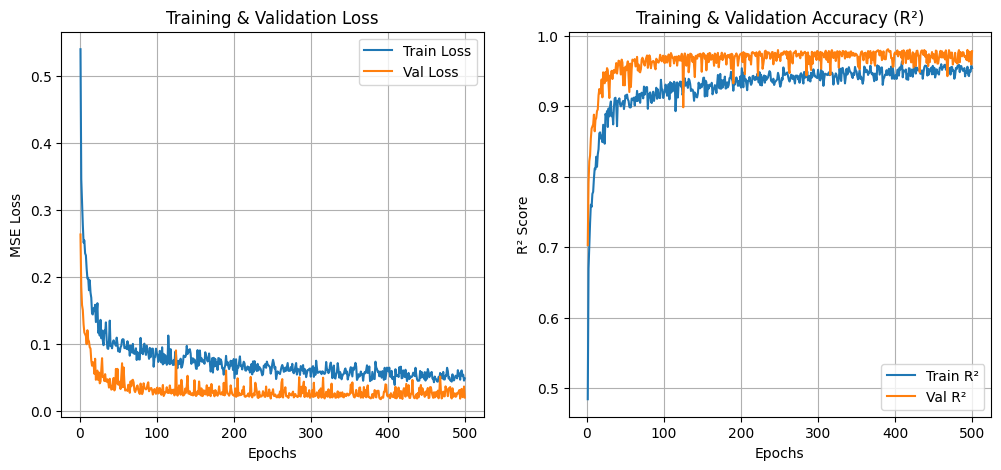


Final Test Results -> Loss: 0.018952, R²: 0.979


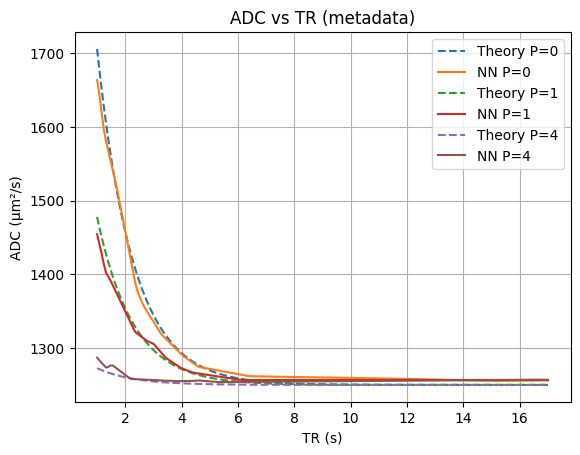

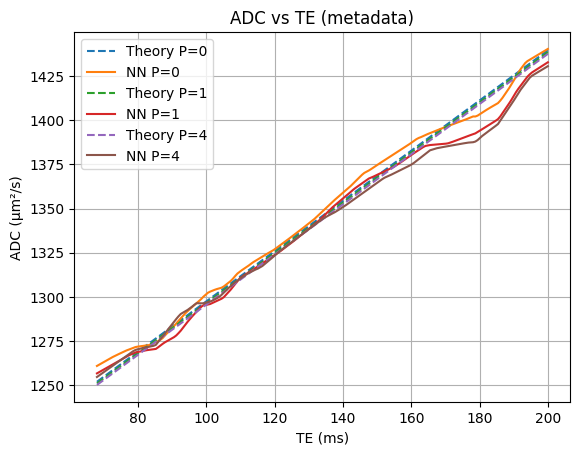

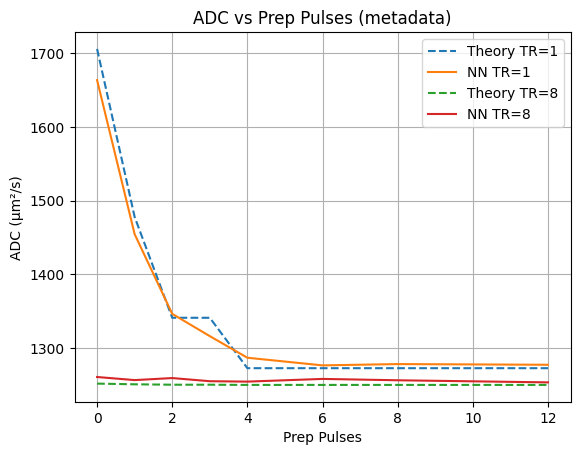

In [8]:
# ======================================================
# Unified Synthetic Phantom ADC Pipeline - Metadata & Signal
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score

# ----------------------------
# 1. Phantom parameters
# ----------------------------
T1 = 1.273  # s
T2 = 0.315  # s
ADC_true_base = 1.25e-3  # true ADC in mm^2/s
delta_adc = 1.0e-3  # overestimation at very short TR
prep_factor = {0:1.0,1:0.5,2:0.2,3:0.2,4:0.05,6:0.05,8:0.05,12:0.05}

TR_list = np.array([1,1.5,2,3,4,5,6,7,8,10,12,14,16,17])
TE_list = np.array([68,80,100,120,140,160,200])
NEX_list = np.array([1,2,4,8,12,16])
Prep_list = np.array([0,1,2,3,4,6,8,12])

N_SAMPLES = 5000

# ----------------------------
# 2. Choose ADC type
# ----------------------------
adc_type = 'metadata'  # or 'signal'

# ----------------------------
# 3. Generate ADC samples
# ----------------------------
def generate_adc_sample(adc_type='metadata'):
    TR = np.random.choice(TR_list)
    TE = np.random.choice(TE_list)
    NEX = np.random.choice(NEX_list)
    Prep = np.random.choice(Prep_list)
    beta = prep_factor.get(Prep,0.1)

    if adc_type=='metadata':
        ADC_eff = ADC_true_base + delta_adc*beta*np.exp(-TR/T1)
        alpha = 0.15
        ADC_eff *= (1 + alpha*(TE-68)/132)
    elif adc_type=='signal':
        ADC_eff = ADC_true_base + delta_adc*beta*np.exp(-TR/T1)
    else:
        raise ValueError("adc_type must be 'metadata' or 'signal'")

    ADC_eff += np.random.normal(0,1e-5)
    return np.array([TR,TE,NEX,Prep],dtype=np.float32), ADC_eff

def create_dataset(n_samples=N_SAMPLES, scale=1e6, adc_type='metadata'):
    X, Y = [], []
    for _ in range(n_samples):
        meta, adc = generate_adc_sample(adc_type)
        X.append(meta)
        Y.append(adc*scale)  # µm²/s
    return np.array(X), np.array(Y)

# ------------------------
# 4. PyTorch Dataset
# ------------------------
class ADCDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.Y_mean = Y.mean()
        self.Y_std = Y.std()
        self.Y = torch.tensor((Y - self.Y_mean)/self.Y_std,dtype=torch.float32)
    def __len__(self):
        return len(self.Y)
    def __getitem__(self,idx):
        return self.X[idx], self.Y[idx]

# ------------------------
# 5. Neural Network
# ------------------------
class ADCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(4,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.fc(x).squeeze(1)

# ------------------------
# 6. Train/Test split
# ------------------------
X, Y = create_dataset(n_samples=N_SAMPLES, scale=1e6, adc_type=adc_type)
dataset = ADCDataset(X,Y)
n_train = int(0.7*len(dataset))
n_val = int(0.15*len(dataset))
n_test = len(dataset)-n_train-n_val
train_set,val_set,test_set = random_split(dataset,[n_train,n_val,n_test])

train_loader = DataLoader(train_set,batch_size=64,shuffle=True)
val_loader = DataLoader(val_set,batch_size=64,shuffle=False)
test_loader = DataLoader(test_set,batch_size=64,shuffle=False)

# ------------------------
# 7. Train function with R²
# ------------------------
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device="cpu"):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}
    
    for epoch in range(1, epochs+1):
        # --- Training ---
        model.train()
        train_loss, y_true_train, y_pred_train = 0, [], []
        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, Yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            y_true_train.extend(Yb.cpu().numpy())
            y_pred_train.extend(out.detach().cpu().numpy())
        train_loss /= len(train_loader.dataset)
        train_r2 = r2_score(y_true_train, y_pred_train)

        # --- Validation ---
        model.eval()
        val_loss, y_true_val, y_pred_val = 0, [], []
        with torch.no_grad():
            for Xb, Yb in val_loader:
                Xb, Yb = Xb.to(device), Yb.to(device)
                out = model(Xb)
                val_loss += criterion(out, Yb).item() * Xb.size(0)
                y_true_val.extend(Yb.cpu().numpy())
                y_pred_val.extend(out.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        val_r2 = r2_score(y_true_val, y_pred_val)

        # Save history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_r2"].append(train_r2)
        history["val_r2"].append(val_r2)

        print(f"Epoch {epoch:03d}: "
              f"train_loss={train_loss:.6f}, val_loss={val_loss:.6f}, "
              f"train_r2={train_r2:.3f}, val_r2={val_r2:.3f}")
    
    return history

# ------------------------
# 8. Training
# ------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ADCNet()
history = train_model(model, train_loader, val_loader, epochs=500, lr=1e-3, device=device)

# ------------------------
# 9. Training Curves (Loss + R²)
# ------------------------
epochs = range(1, len(history["train_loss"])+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, history["train_r2"], label="Train R²")
plt.plot(epochs, history["val_r2"], label="Val R²")
plt.xlabel("Epochs"); plt.ylabel("R² Score")
plt.title("Training & Validation Accuracy (R²)")
plt.legend(); plt.grid(True)

plt.show()

# ------------------------
# 10. Final Test Evaluation
# ------------------------
model.eval()
y_true_test, y_pred_test = [], []
criterion = nn.MSELoss()
test_loss = 0

with torch.no_grad():
    for Xb, Yb in test_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)
        out = model(Xb)
        test_loss += criterion(out, Yb).item() * Xb.size(0)
        y_true_test.extend(Yb.cpu().numpy())
        y_pred_test.extend(out.cpu().numpy())

test_loss /= len(test_loader.dataset)
test_r2 = r2_score(y_true_test, y_pred_test)
print(f"\nFinal Test Results -> Loss: {test_loss:.6f}, R²: {test_r2:.3f}")

# ------------------------
# 11. Prediction helper
# ------------------------
def predict_sweep(model, param_name, sweep_vals, fixed_vals, dataset):
    model.eval()
    preds = []
    for val in sweep_vals:
        meta = fixed_vals.copy()
        meta[param_name] = val
        meta_array = np.array([meta['TR'], meta['TE'], meta['NEX'], meta['Prep']], dtype=np.float32)
        meta_tensor = torch.tensor(meta_array.reshape(1,-1),dtype=torch.float32).to(device)
        with torch.no_grad():
            out = model(meta_tensor)
            out = out.cpu().numpy() * dataset.Y_std + dataset.Y_mean
        preds.append(out.item())
    return np.array(preds)

# ------------------------
# 12. Plots: ADC vs TR/TE/Prep
# ------------------------
prep_vals = [0,1,4]
TR_cont = np.linspace(1,17,200)
TE_cont = np.linspace(68,200,200)
Prep_cont = np.array([0,1,2,3,4,6,8,12])

# ADC vs TR
plt.figure()
for prep in prep_vals:
    beta = prep_factor.get(prep,0.1)
    if adc_type=='metadata':
        adc_theory = (ADC_true_base + delta_adc*beta*np.exp(-TR_cont/T1))*(1+0.15*(68-68)/132)*1e6
    else:
        adc_theory = (ADC_true_base + delta_adc*beta*np.exp(-TR_cont/T1))*1e6
    plt.plot(TR_cont, adc_theory,'--',label=f"Theory P={prep}")
    fixed = {"TR":8,"TE":68,"NEX":1,"Prep":prep}
    adc_nn = predict_sweep(model,"TR",TR_cont,fixed,dataset)
    plt.plot(TR_cont, adc_nn,label=f"NN P={prep}")
plt.xlabel("TR (s)"); plt.ylabel("ADC (µm²/s)")
plt.title(f"ADC vs TR ({adc_type})")
plt.grid(True); plt.legend(); plt.show()

# ADC vs TE
plt.figure()
for prep in prep_vals:
    beta = prep_factor.get(prep,0.1)
    if adc_type=='metadata':
        adc_theory = (ADC_true_base + delta_adc*beta*np.exp(-8/T1))*(1 + 0.15*(TE_cont-68)/132)*1e6
    else:
        adc_theory = (ADC_true_base + delta_adc*beta*np.exp(-8/T1))*np.ones_like(TE_cont)*1e6
    plt.plot(TE_cont, adc_theory,'--',label=f"Theory P={prep}")
    fixed = {"TR":8,"TE":68,"NEX":1,"Prep":prep}
    adc_nn = predict_sweep(model,"TE",TE_cont,fixed,dataset)
    plt.plot(TE_cont, adc_nn,label=f"NN P={prep}")
plt.xlabel("TE (ms)"); plt.ylabel("ADC (µm²/s)")
plt.title(f"ADC vs TE ({adc_type})")
plt.grid(True); plt.legend(); plt.show()

# ADC vs Prep
plt.figure()
for TR_fixed in [1,8]:
    adc_theory = []
    for prep in Prep_cont:
        beta = prep_factor.get(prep,0.1)
        adc_theory.append((ADC_true_base + delta_adc*beta*np.exp(-TR_fixed/T1))*1e6)
    plt.plot(Prep_cont, adc_theory,'--',label=f"Theory TR={TR_fixed}")
    pred_nn = []
    for prep in Prep_cont:
        fixed = {"TR":TR_fixed,"TE":68,"NEX":1,"Prep":prep}
        pred_nn.append(predict_sweep(model,"Prep",[prep],fixed,dataset)[0])
    plt.plot(Prep_cont, pred_nn,label=f"NN TR={TR_fixed}")
plt.xlabel("Prep Pulses"); plt.ylabel("ADC (µm²/s)")
plt.title(f"ADC vs Prep Pulses ({adc_type})")
plt.grid(True); plt.legend(); plt.show()
